In [65]:
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["figure.figsize"] = (12,6)

# NumPy

**Задача 1**\
Сгенерировать массив из случайных положительных чисел произвольной длины. Вывести элементы, которые больше среднего арифметического.

In [66]:
data = np.array(np.random.randint(1000, size=10))
data

array([876, 860, 747, 654, 160, 898,  53, 270, 635, 637])

In [67]:
data[data > np.mean(data)]

array([876, 860, 747, 654, 898, 635, 637])

**Задача 2**\
Сгенерировать массив из 20 случайных элементов, элементы которого лежат в интервале [0, 10].
+ Определить количество элементов, отличающихся от минимального на 5.
+ Найти среднее арифметическое всех четных элементов массива, стоящих на нечетных местах.

In [68]:
arr = np.array(np.random.randint(11, size=20))
arr

array([6, 3, 8, 3, 2, 2, 8, 2, 7, 1, 6, 8, 3, 5, 0, 0, 1, 7, 9, 3])

In [69]:
arr[(arr-np.min(arr)) == 5].shape[0]

1

In [70]:
arr1 = arr[1::2]
arr1

array([3, 3, 2, 2, 1, 8, 5, 0, 7, 3])

In [71]:
np.mean(arr1[arr1%2 == 0])

3.0

**Задача 3**\
Сгенерировать матрицу A размером 5 на 5, элементы которой лежат в интервале [1, 10].
+ Возвести в квадрат максимальный элемент матрицы.
+ Все четные числа заменить на 0.

In [72]:
A = np.random.randint(1, 11, size=(5, 5))

In [73]:
A = np.where(A == np.max(A), A **2, A)
A

array([[  5,   1,   4,   2,   4],
       [  1,   4,   8,   1,   9],
       [  4,   3,   6,   5,   8],
       [  4,   1,   9,   7,   3],
       [100,   9, 100,   9,   3]])

In [74]:
A = np.where(A%2 == 0, 0, A)
A

array([[5, 1, 0, 0, 0],
       [1, 0, 0, 1, 9],
       [0, 3, 0, 5, 0],
       [0, 1, 9, 7, 3],
       [0, 9, 0, 9, 3]])

**Задача 4**\
Сгенерировать матрицу B размером 5 на 5, элементы которой лежат в интервале [-5, 5]. Отрицательные элементы матрицы заменить на число отрицательных элементов в строке, в которой они находятся.

In [75]:
B = np.random.randint(-5, 6, size=(5, 5))
B

array([[-1, -2,  5,  4,  3],
       [ 1, -2,  5, -3,  5],
       [-4,  4, -4, -1, -3],
       [ 4, -4, -3,  0, -5],
       [ 5,  2,  4, -3,  1]])

In [76]:
for i in range(B.shape[0]):
    negative_count = np.sum(B[i, :] < 0)
    B[i, B[i, :] < 0] = negative_count 
B

array([[2, 2, 5, 4, 3],
       [1, 2, 5, 2, 5],
       [4, 4, 4, 4, 4],
       [4, 3, 3, 0, 3],
       [5, 2, 4, 1, 1]])

# Pandas

In [77]:
df = pd.read_csv("https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv")

**Задание 1**
+ Какой была максимальная цена билета? Медиана?
+ Какова доля выживших?
+ Сколько мужчин / женщин находилось на борту?

In [78]:
df[0:3]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [80]:
df['fare'].max()

512.3292

In [81]:
df['fare'].median()

14.4542

In [82]:
round(df['survived'].value_counts(normalize=True)*100, 2)

0    61.8
1    38.2
Name: survived, dtype: float64

**Задание 2**
+ Выведите распределение переменной __pclass__ для мужчин и женщин.
    + Сколько мужчин было в первом классе?
    + Сколько женщин было в третьем классе?
      
+ Создайте новый признак __age_group__, который равен:
    + 1, если пассажир был моложе 30 лет;
    + 2, если пассажиру было от 30 до 60 лет;
    + 3, если пассажир был старше 60 лет.

In [83]:
import seaborn as sns

<Axes: xlabel='pclass', ylabel='count'>

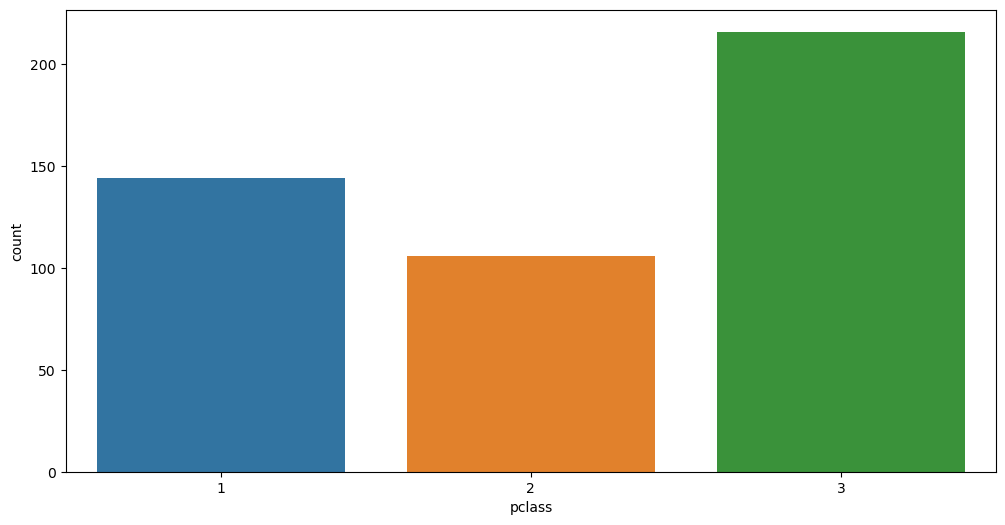

In [84]:
sns.countplot(x='pclass', data=df[df['sex'] == 'female'])

<Axes: xlabel='pclass', ylabel='count'>

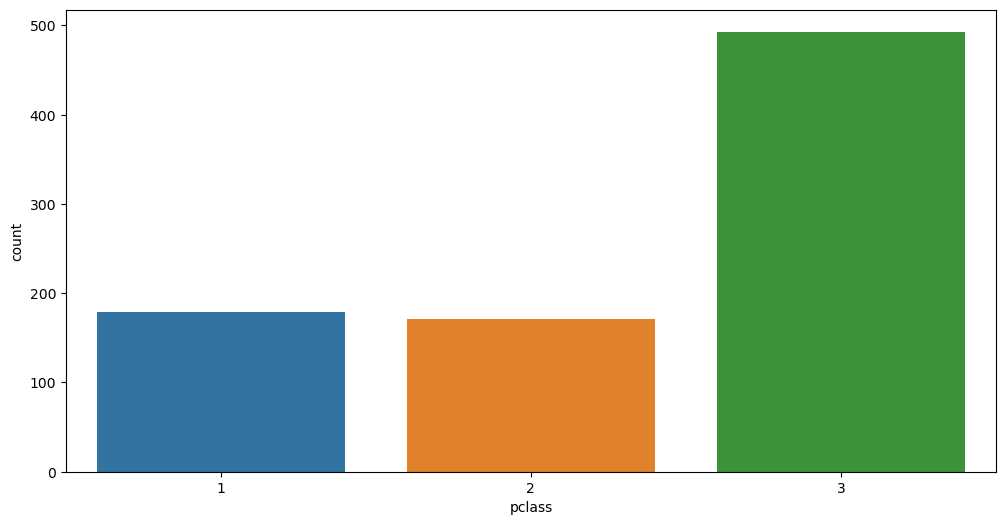

In [85]:
sns.countplot(x='pclass', data=df[df['sex'] == 'male'])

In [86]:
df[(df['sex'] == 'male') & (df['pclass'] == 1)].count()[0]

179

In [87]:
df[(df['sex'] == 'female') & (df['pclass'] == 3)].count()[0]

216

In [88]:
def fun(x):
    if x < 30:
        return 1
    elif x >= 30 and x <= 60:
        return 2
    elif x > 60:
        return 3

In [89]:
df['age_group'] = df['age'].apply(lambda x: fun(x))

In [90]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1.0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1.0
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1.0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",2.0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,1.0
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,1.0
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,1.0


**Задание 3**\
Найдите самое популярное имя среди пассажиров:
+ мужчин;
+ женщин.

In [191]:
data1 = df[(df['sex'] == 'male')]

In [192]:
data1['name1'] = data1['name'].apply(lambda x: x.split(',')[0])

C:\Users\mirwo\AppData\Local\Temp\ipykernel_36164\4015019254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['name1'] = data1['name'].apply(lambda x: x.split(',')[0])


In [199]:
data1['name1'].value_counts().sort_values(ascending=False).head(1)

Davies    6
Name: name1, dtype: int64

In [200]:
data2 = df[(df['sex'] == 'female')]
data2['name1'] = data2['name'].apply(lambda x: x.split(',')[0])
data2['name1'].value_counts().sort_values(ascending=False).head(1)

C:\Users\mirwo\AppData\Local\Temp\ipykernel_36164\2645440602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['name1'] = data2['name'].apply(lambda x: x.split(',')[0])


Andersson    7
Name: name1, dtype: int64

**Задание 4**
+ Выведите данные о всех пассажирах, которые сели в Cherbourg (Embarked='C') и были старше 50 лет.
+ Выведите данные о всех женщинах младше 20 и старше 50 лет.
+ Сколько пассажиров старше 70 лет было на борту?

In [202]:
df[(df['embarked'] == 'C') & (df['age'] > 50)]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay",3.0
43,1,1,"Bucknell, Mrs. William Robert (Emma Eliza Ward)",female,60.0,0,0,11813,76.2917,D15,C,8,NaN,"Philadelphia, PA",2.0
48,1,1,"Candee, Mrs. Edward (Helen Churchill Hungerford)",female,53.0,0,0,PC 17606,27.4458,NaN,C,6,NaN,"Washington, DC",2.0
50,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,3,NaN,"Germantown, Philadelphia, PA",2.0
78,1,1,"Compton, Mrs. Alexander Taylor (Mary Eliza Ing...",female,64.0,0,2,PC 17756,83.1583,E45,C,14,NaN,"Lakewood, NJ",3.0
104,1,1,"Eustis, Miss. Elizabeth Mussey",female,54.0,1,0,36947,78.2667,D20,C,4,NaN,"Brookline, MA",2.0
123,1,1,"Frolicher-Stehli, Mr. Maxmillian",male,60.0,1,1,13567,79.2000,B41,C,5,NaN,"Zurich, Switzerland",2.0
135,1,0,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C,NaN,NaN,"New York, NY",3.0
136,1,1,"Gracie, Col. Archibald IV",male,53.0,0,0,113780,28.5000,C51,C,B,NaN,"Washington, DC",2.0
174,1,0,"Kent, Mr. Edward Austin",male,58.0,0,0,11771,29.7000,B37,C,NaN,258.0,"Buffalo, NY",2.0


In [205]:
df[(df['sex'] == 'female') & ((df['age'] > 50) | (df['age'] < 20))]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group
2,1,0,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1.0
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY",3.0
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY",2.0
11,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C,4,NaN,"New York, NY",1.0
27,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,B49,C,7,NaN,"Dowagiac, MI",1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,3,0,"Van Impe, Miss. Catharina",female,10.0,0,2,345773,24.1500,NaN,S,NaN,NaN,NaN,1.0
1273,3,0,"Vander Planke, Miss. Augusta Maria",female,18.0,2,0,345764,18.0000,NaN,S,NaN,NaN,NaN,1.0
1279,3,0,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S,NaN,NaN,NaN,1.0
1300,3,1,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1,0,2659,14.4542,NaN,C,NaN,NaN,NaN,1.0


In [207]:
df[(df['age'] > 70)]['name'].count()

6

**Задание 5**
+ Посчитайте средний возраст среди мужчин и среди женщин.
+ Посчитайте доли выживших в различных возрастных группах (новый признак **AgeGroup**).
+ Найдите максимальную стоимость билета в каждом из ценовых классов.

In [208]:
data1['age'].mean()

30.5852329787234

In [209]:
data2['age'].mean()

28.6870706185567

In [212]:
df.pivot_table(values='survived', columns='age_group')

age_group,1.0,2.0,3.0
survived,0.40949,0.418919,0.242424


In [214]:
df.pivot_table(values='fare', columns='pclass', aggfunc='max')

pclass,1,2,3
fare,512.3292,73.5,69.55


**Задание 6**\
Ответьте на предыдущие вопросы с помощью функции crosstab и метода pivot_table.

задание 1

In [241]:
df.pivot_table(aggfunc=['max','median'], index='sex',values='fare').reset_index()

,sex,max,median
,,fare,fare
0,female,512.3292,23.0000
1,male,512.3292,11.8875
